# Modélisation KNN — Classification des alertes cybersécurité Microsoft

**Branche :** `Guyjc-Modélisation`  
**Auteur :** Guy Junior Calvet  
**Objectif :** Construire un modèle K-Nearest Neighbors (KNN) optimisé pour classifier les incidents de sécurité Microsoft en 3 classes : `BenignPositive`, `FalsePositive`, `TruePositive`.

---

### Architecture
Le **prétraitement et l'exploration des données** sont réalisés dans `notebook.ipynb` (branche `main`). Ce fichier exporte un CSV prétraité (`donnees_preprocessees.csv`) que le présent notebook charge directement pour la **modélisation**.

### Pipeline de modélisation
1. **Chargement des données prétraitées** via `donnees_preprocessees.csv`
2. **Réduction de dimensionnalité par ACP (PCA)** — compression des features
3. **Modèle KNN de base** (baseline K=5)
4. **Recherche du K optimal** (Elbow Method + Cross-Validation)
5. **Optimisation par GridSearchCV** (hyperparamètres complets)
6. **Évaluation finale** (métriques, matrice de confusion, rapport de classification)

### Sources & Références
- Scikit-learn KNN : https://scikit-learn.org/stable/modules/neighbors.html
- Scikit-learn PCA : https://scikit-learn.org/stable/modules/decomposition.html#pca
- Dataset GUIDE : https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction
- Cover, T. & Hart, P. (1967). *Nearest neighbor pattern classification*. IEEE Transactions on Information Theory.
- Scikit-learn GridSearchCV : https://scikit-learn.org/stable/modules/grid_search.html.
- Notes de cours (Forage des données et Analyse statistiques des données de masse)

---
## 1. Importation des bibliothèques

In [ ]:
# -- Bibliotheques standard --
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# -- Scikit-learn : modelisation --
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# -- Scikit-learn : metriques --
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score,
    precision_score, recall_score
)

# -- Constantes --
CIBLE_MAP = {'BenignPositive': 0, 'FalsePositive': 1, 'TruePositive': 2}
CIBLE_MAP_INV = {v: k for k, v in CIBLE_MAP.items()}

print("Bibliotheques importees avec succes.")

✅ Bibliothèques importées avec succès.


---
## 2. Chargement des donnees pretraitees et transformation

Les donnees ont ete **pretraitees et explorees** dans `notebook.ipynb` (branche `main`) et sauvegardees dans `donnees_preprocessees.csv`. Le pretraitement comprend :

| Etape | Action |
|-------|--------|
| **Selection** | 14 colonnes utiles, suppression des identifiants |
| **NaN** | Remplissage par `'Unknown'` / `'None'` selon la colonne |
| **Cardinalite** | `MitreTechniques` top 15 ; colonnes geo top N |
| **Features** | `IsWeekend`, `IsBusinessHour` ; `RegistryValueData` en str |
| **Cible** | `BenignPositive=0`, `FalsePositive=1`, `TruePositive=2` |

Ce notebook effectue le **split train/test** et la **transformation** (StandardScaler + OneHotEncoder) avant la modelisation.

In [ ]:
# -- 2.1 Chargement du dataset pretraite --
df = pd.read_csv("donnees_preprocessees.csv", low_memory=False)
print(f"Dimensions : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")

# Separation X / y
X = df.drop(columns=['cible'])
y = df['cible']

# Identifier les colonnes numeriques et categorielles
num_cols = X.select_dtypes(exclude='object').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype(str)

print(f"\n  Numeriques    ({len(num_cols)}) : {num_cols}")
print(f"  Categorielles ({len(cat_cols)}) : {cat_cols}")
print(f"\n  Distribution cible :")
print(y.map(CIBLE_MAP_INV).value_counts().to_string())

# -- 2.2 Split stratifie (80/20) --
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026, stratify=y
)
print(f"\n  Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")

# -- 2.3 Transformation (StandardScaler + OneHotEncoder) --
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                              sparse_output=False), cat_cols),
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

print(f"\n  Dimensionnalite apres OneHotEncoding : {X_train_transformed.shape[1]} features")
print(f"  Train : {X_train_transformed.shape}  |  Test : {X_test_transformed.shape}")

Dimensions : 94,638 lignes × 15 colonnes

  Numériques    (4) : ['RegistryValueData', 'OSFamily', 'IsWeekend', 'IsBusinessHour']
  Catégorielles (10) : ['Category', 'EntityType', 'EvidenceRole', 'OSVersion', 'SuspicionLevel', 'LastVerdict', 'CountryCode', 'State', 'City', 'MitreTechnique_Main']

  Distribution cible :
cible
BenignPositive    41105
TruePositive      33220
FalsePositive     20313

  Train : 75,710  |  Test : 18,928

  Dimensionnalité après OneHotEncoding : 146 features
  Train : (75710, 146)  |  Test : (18928, 146)

  Dimensionnalité après OneHotEncoding : 146 features
  Train : (75710, 146)  |  Test : (18928, 146)


---
## 3. Réduction de dimensionnalité — Analyse en Composantes Principales (ACP / PCA)

### Pourquoi appliquer la PCA ?
Après le `OneHotEncoding`, le nombre de features augmente considérablement (~173 dimensions). Or, KNN est particulièrement sensible à la **malédiction de la dimensionnalité** (Bellman, 1961) : dans un espace de grande dimension, les distances entre points deviennent quasi uniformes, réduisant le pouvoir discriminant du modèle.

La PCA projette les données dans un sous-espace de dimension réduite tout en conservant le maximum de **variance expliquée** :

$$\mathbf{Z} = \mathbf{X} \mathbf{W}_K \quad \text{où } \mathbf{W}_K \in \mathbb{R}^{p \times K}$$

avec $K \ll p$ composantes principales retenues.

### Seuil retenu : 95% de la variance
On conserve le nombre minimal de composantes qui expliquent au moins **95%** de la variance totale — un seuil standard en apprentissage automatique (Jolliffe, 2002).

**Réf.** :
- Jolliffe, I. T. (2002). *Principal Component Analysis*. Springer, 2ᵉ éd.
- Bellman, R. (1961). *Adaptive Control Processes*. Princeton University Press.
- https://scikit-learn.org/stable/modules/decomposition.html#pca

In [ ]:
# -- 3.1 Analyse de la variance expliquee --

# Fit PCA complet pour analyser la distribution de la variance
pca_full = PCA(random_state=2026)
pca_full.fit(X_train_transformed)

variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_)

# Nombre de composantes pour 95% de variance
n_composantes_95 = np.argmax(variance_cumulee >= 0.95) + 1

print(f"Dimensions originales : {X_train_transformed.shape[1]} features")
print(f"Composantes pour 95% de variance : {n_composantes_95}")
print(f"Taux de compression : {(1 - n_composantes_95/X_train_transformed.shape[1])*100:.1f}%")
print(f"\nVariance expliquee par les 5 premieres composantes :")
for i in range(5):
    print(f"  PC{i+1} : {pca_full.explained_variance_ratio_[i]*100:.2f}%  (cumule : {variance_cumulee[i]*100:.2f}%)")

Dimensions originales : 146 features
Composantes pour 95% de variance : 24
Taux de compression : 83.6%

Variance expliquée par les 5 premières composantes :
  PC1 : 15.97%  (cumulé : 15.97%)
  PC2 : 14.38%  (cumulé : 30.35%)
  PC3 : 13.39%  (cumulé : 43.74%)
  PC4 : 12.39%  (cumulé : 56.13%)
  PC5 : 7.67%  (cumulé : 63.80%)


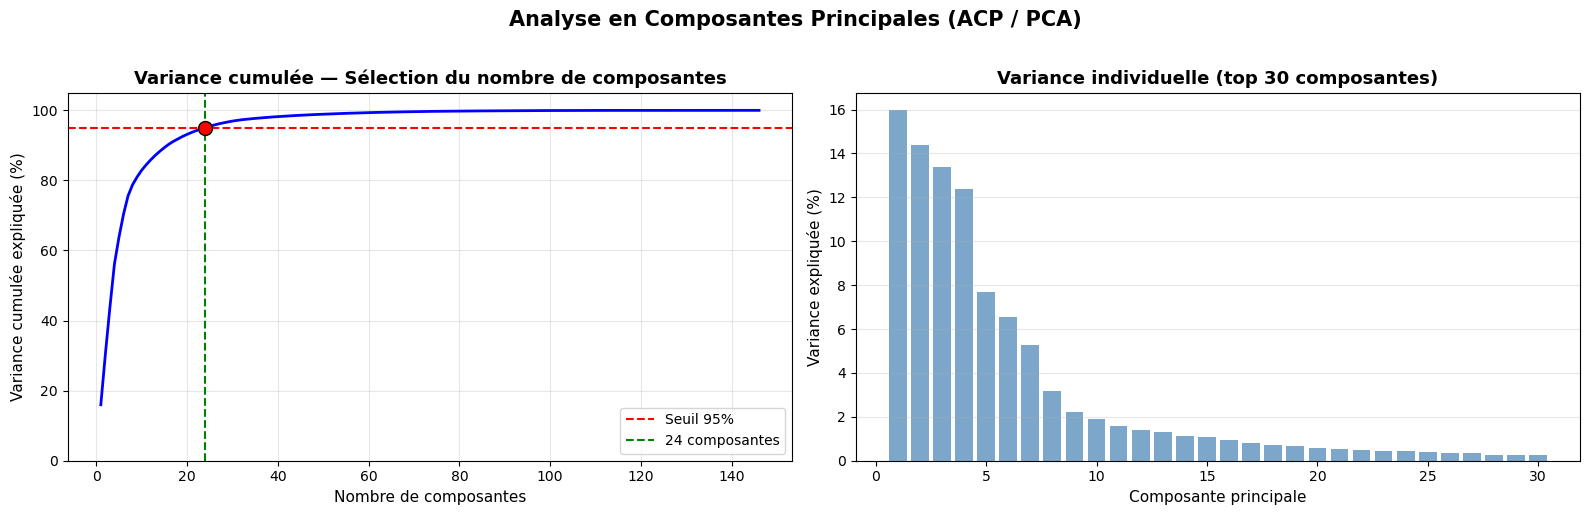


📌 On retient 24 composantes (95% de variance, compression de 84%)


In [ ]:
# -- 3.2 Visualisation de la variance cumulee --

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphique 1 : Variance cumulee
axes[0].plot(range(1, len(variance_cumulee) + 1), variance_cumulee * 100, 'b-', linewidth=2)
axes[0].axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='Seuil 95%')
axes[0].axvline(x=n_composantes_95, color='green', linestyle='--', linewidth=1.5,
                label=f'{n_composantes_95} composantes')
axes[0].scatter([n_composantes_95], [95], color='red', s=100, zorder=5, edgecolors='black')
axes[0].set_xlabel('Nombre de composantes', fontsize=11)
axes[0].set_ylabel('Variance cumulee expliquee (%)', fontsize=11)
axes[0].set_title('Variance cumulee -- Selection du nombre de composantes',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 105)

# Graphique 2 : Variance individuelle (top 30 composantes)
n_show = min(30, len(pca_full.explained_variance_ratio_))
axes[1].bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
            color='steelblue', alpha=0.7)
axes[1].set_xlabel('Composante principale', fontsize=11)
axes[1].set_ylabel('Variance expliquee (%)', fontsize=11)
axes[1].set_title(f'Variance individuelle (top {n_show} composantes)',
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Analyse en Composantes Principales (ACP / PCA)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nOn retient {n_composantes_95} composantes (95% de variance, "
      f"compression de {(1 - n_composantes_95/X_train_transformed.shape[1])*100:.0f}%)")

In [ ]:
# -- 3.3 Application de la PCA (95% de variance) --

pca = PCA(n_components=0.95, random_state=2026)
X_train_pca = pca.fit_transform(X_train_transformed)
X_test_pca  = pca.transform(X_test_transformed)

print(f"Transformation PCA appliquee :")
print(f"  Train : {X_train_transformed.shape} -> {X_train_pca.shape}")
print(f"  Test  : {X_test_transformed.shape} -> {X_test_pca.shape}")
print(f"  Composantes retenues : {pca.n_components_}")
print(f"  Variance expliquee   : {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\nDonnees pretes pour la modelisation KNN avec PCA.")

Transformation PCA appliquée :
  Train : (75710, 146) → (75710, 24)
  Test  : (18928, 146) → (18928, 24)
  Composantes retenues : 24
  Variance expliquée   : 95.08%

✅ Données prêtes pour la modélisation KNN avec PCA.


---
## 4. Modèle KNN Baseline (K=5) — Sans PCA vs Avec PCA

On commence par un modèle KNN de référence avec `K=5` (valeur par défaut scikit-learn) pour établir une **baseline** avant toute optimisation. On compare les performances **sans** et **avec** la réduction PCA pour quantifier son impact.

### Rappel théorique : K-Nearest Neighbors
$$\hat{y}(x) = \arg\max_{c} \sum_{i \in \mathcal{N}_K(x)} \mathbb{1}(y_i = c)$$

où $\mathcal{N}_K(x)$ est l'ensemble des K plus proches voisins de $x$.

**Réf.** :
- Cover, T. & Hart, P. (1967). *Nearest neighbor pattern classification*. IEEE Trans. on Information Theory, 13(1), 21-27.
- https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [ ]:
# -- 4.1 KNN Baseline (K=5) -- Sans PCA vs Avec PCA --

# --- Sans PCA (toutes les features) ---
knn_baseline_nopca = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn_baseline_nopca.fit(X_train_transformed, y_train)
y_pred_bl_nopca = knn_baseline_nopca.predict(X_test_transformed)

acc_bl_nopca = accuracy_score(y_test, y_pred_bl_nopca)
f1_bl_nopca  = f1_score(y_test, y_pred_bl_nopca, average='macro')

# --- Avec PCA ---
knn_baseline = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn_baseline.fit(X_train_pca, y_train)
y_pred_baseline = knn_baseline.predict(X_test_pca)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline  = f1_score(y_test, y_pred_baseline, average='macro')

print("=" * 65)
print("        KNN BASELINE (K=5) -- IMPACT DE LA PCA")
print("=" * 65)
print(f"\n  {'Configuration':<25} {'Accuracy':>10} {'Macro F1':>10} {'Features':>10}")
print(f"  {'-' * 55}")
print(f"  {'Sans PCA':<25} {acc_bl_nopca:>10.4f} {f1_bl_nopca:>10.4f} {X_train_transformed.shape[1]:>10}")
print(f"  {'Avec PCA (95% var.)':<25} {acc_baseline:>10.4f} {f1_baseline:>10.4f} {X_train_pca.shape[1]:>10}")
print(f"\n  Delta F1 (PCA - Sans PCA) : {f1_baseline - f1_bl_nopca:+.4f}")
print(f"  Compression : {X_train_transformed.shape[1]} -> {X_train_pca.shape[1]} features "
      f"(-{(1 - X_train_pca.shape[1]/X_train_transformed.shape[1])*100:.0f}%)")
print(f"\n{'-' * 65}")
print("\nRapport de classification (Avec PCA) :")
print(classification_report(
    y_test, y_pred_baseline,
    target_names=['BenignPositive', 'FalsePositive', 'TruePositive']
))

        KNN BASELINE (K=5) — IMPACT DE LA PCA

  Configuration               Accuracy   Macro F1   Features
  ───────────────────────────────────────────────────────
  Sans PCA                      0.6004     0.5585        146
  Avec PCA (95% var.)           0.6012     0.5594         24

  Δ F1 (PCA - Sans PCA) : +0.0010
  Compression : 146 → 24 features (−84%)

─────────────────────────────────────────────────────────────────

Rapport de classification (Avec PCA) :
                precision    recall  f1-score   support

BenignPositive       0.62      0.73      0.67      8221
 FalsePositive       0.45      0.33      0.38      4063
  TruePositive       0.65      0.61      0.63      6644

      accuracy                           0.60     18928
     macro avg       0.57      0.56      0.56     18928
  weighted avg       0.59      0.60      0.59     18928



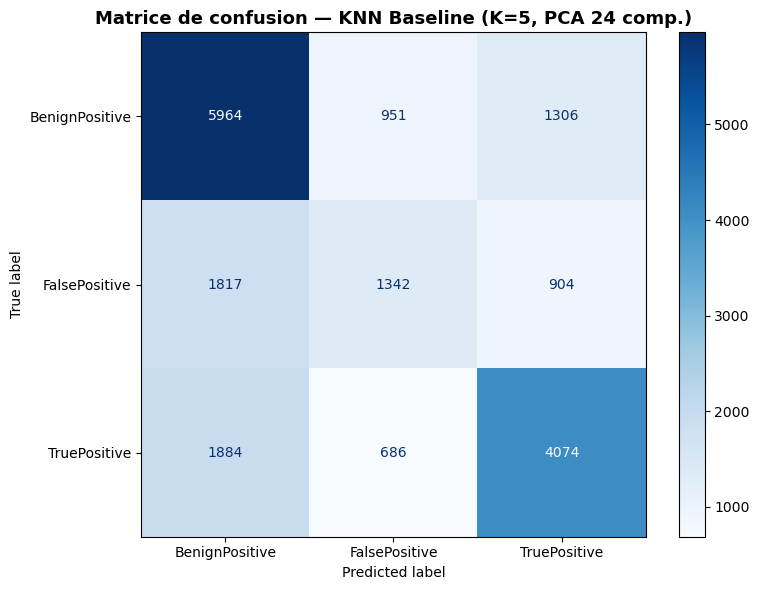

In [ ]:
# -- 4.2 Matrice de confusion -- Baseline avec PCA --
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    display_labels=['BenignPositive', 'FalsePositive', 'TruePositive'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matrice de confusion -- KNN Baseline (K=5, PCA {X_train_pca.shape[1]} comp.)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Recherche du K optimal -- Elbow Method avec Cross-Validation

### Methodologie
Le choix de K est l'hyperparametre le plus critique pour KNN :
- **K trop petit** : surapprentissage (sensibilite au bruit)
- **K trop grand** : sous-apprentissage (frontieres trop lissees)

On utilise la **methode du coude (Elbow Method)** combinee a une **validation croisee stratifiee a 3 plis** sur les donnees reduites par PCA. Avec ~75 000 lignes d'entrainement, 3 folds offrent un bon compromis : chaque fold de validation contient ~25 000 observations, ce qui est largement suffisant pour une estimation stable des performances.

> **Regle heuristique :** $K \approx \sqrt{N}$, mais en pratique des valeurs plus petites fonctionnent souvent mieux.

**Ref.** :
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer. Chap. 13.
- https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html

In [ ]:
# -- 5.1 Elbow Method : K de 1 a 21 (impairs) --
# 3-fold CV sur donnees PCA : ~25k observations par fold = estimation stable

k_range = list(range(1, 22, 2))  # [1, 3, 5, 7, ..., 21]
cv_scores_mean = []
cv_scores_std  = []

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=2026)

print(f"Recherche du K optimal ({X_train_pca.shape[1]} composantes PCA, 3-fold CV)")
print(f"K testes : {k_range}\n")

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(knn, X_train_pca, y_train, cv=skf,
                             scoring='f1_macro', n_jobs=-1)
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())
    print(f"  K={k:2d}  |  Macro F1 = {scores.mean():.4f} (+/-{scores.std():.4f})")

best_idx = np.argmax(cv_scores_mean)
best_k   = k_range[best_idx]
print(f"\nMeilleur K = {best_k} avec Macro F1 = {cv_scores_mean[best_idx]:.4f}")

Recherche du K optimal (24 composantes PCA, 3-fold CV)
K testés : [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

  K= 1  →  Macro F1 = 0.5286 (±0.0096)
  K= 1  →  Macro F1 = 0.5286 (±0.0096)
  K= 3  →  Macro F1 = 0.5475 (±0.0107)
  K= 3  →  Macro F1 = 0.5475 (±0.0107)
  K= 5  →  Macro F1 = 0.5652 (±0.0051)
  K= 5  →  Macro F1 = 0.5652 (±0.0051)
  K= 7  →  Macro F1 = 0.5701 (±0.0004)
  K= 7  →  Macro F1 = 0.5701 (±0.0004)
  K= 9  →  Macro F1 = 0.5725 (±0.0040)
  K= 9  →  Macro F1 = 0.5725 (±0.0040)
  K=11  →  Macro F1 = 0.5710 (±0.0017)
  K=11  →  Macro F1 = 0.5710 (±0.0017)
  K=13  →  Macro F1 = 0.5712 (±0.0027)
  K=13  →  Macro F1 = 0.5712 (±0.0027)
  K=15  →  Macro F1 = 0.5722 (±0.0028)
  K=15  →  Macro F1 = 0.5722 (±0.0028)
  K=17  →  Macro F1 = 0.5722 (±0.0023)
  K=17  →  Macro F1 = 0.5722 (±0.0023)
  K=19  →  Macro F1 = 0.5745 (±0.0031)
  K=19  →  Macro F1 = 0.5745 (±0.0031)
  K=21  →  Macro F1 = 0.5723 (±0.0022)

✅ Meilleur K = 19 avec Macro F1 = 0.5745
  K=21  →  Macro F1 = 0.5723 (±0

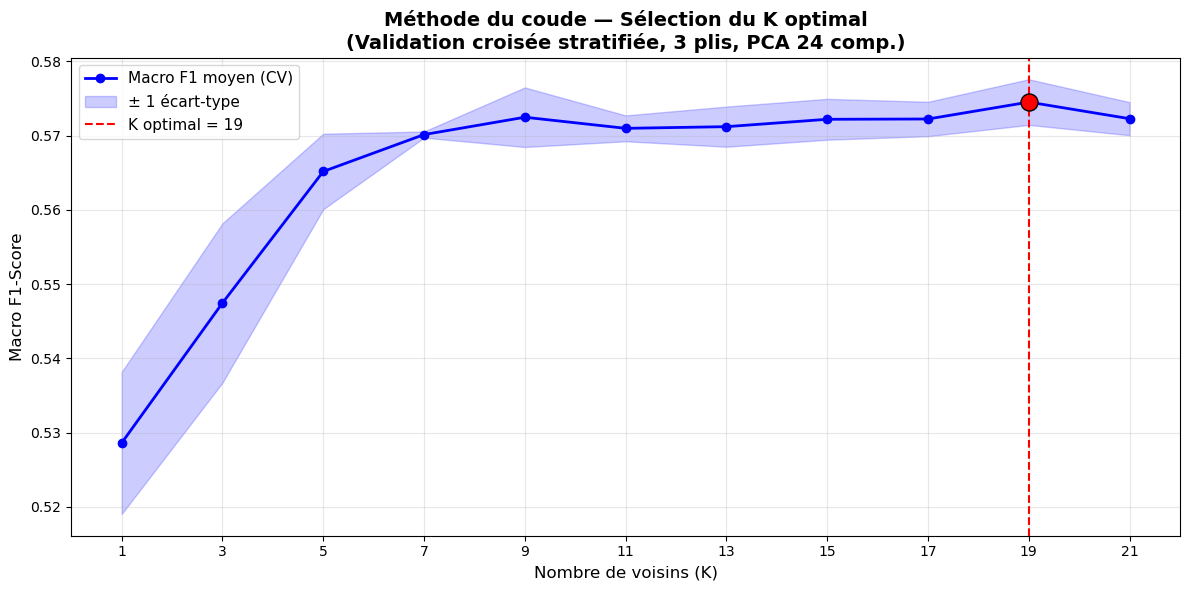


📌 Le K optimal identifié est K = 19
   Macro F1 moyen en CV : 0.5745 (±0.0031)


In [ ]:
# -- 5.2 Visualisation -- Courbe du coude (Elbow Curve) --

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(k_range, cv_scores_mean, 'b-o', linewidth=2, markersize=6, label='Macro F1 moyen (CV)')
ax.fill_between(
    k_range,
    np.array(cv_scores_mean) - np.array(cv_scores_std),
    np.array(cv_scores_mean) + np.array(cv_scores_std),
    alpha=0.2, color='blue', label='+/- 1 ecart-type'
)

# Marquer le meilleur K
ax.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f'K optimal = {best_k}')
ax.scatter([best_k], [cv_scores_mean[best_idx]], color='red', s=150, zorder=5, edgecolors='black')

ax.set_xlabel('Nombre de voisins (K)', fontsize=12)
ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title(f'Methode du coude -- Selection du K optimal\n(Validation croisee stratifiee, 3 plis, PCA {X_train_pca.shape[1]} comp.)',
             fontsize=14, fontweight='bold')
ax.set_xticks(k_range)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLe K optimal identifie est K = {best_k}")
print(f"   Macro F1 moyen en CV : {cv_scores_mean[best_idx]:.4f} (+/-{cv_scores_std[best_idx]:.4f})")

---
## 6. Optimisation fine par GridSearchCV

On affine la recherche avec une **validation croisee a 3 plis** sur les donnees reduites par PCA :

| Hyperparametre | Valeurs testees | Justification |
|----------------|-----------------|---------------|
| `n_neighbors` | Voisinage autour du K optimal | Affiner le meilleur K |
| `weights` | `uniform`, `distance` | Ponderation par l'inverse de la distance |
| `metric` | `minkowski` (p=1, p=2) | Manhattan vs Euclidienne |

### Choix de 3 folds
Avec $N_{\text{train}} \approx 75\,000$, chaque fold de validation contient ~25 000 observations. La faible variance observee durant l'Elbow Method (ecart-type <= 0.007) confirme que 3 folds suffisent pour une estimation fiable, tout en divisant le temps de calcul par ~1.7x par rapport a 5 folds.

**Ref.** :
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- https://scikit-learn.org/stable/modules/neighbors.html#classification

In [ ]:
# -- 6.1 GridSearchCV -- Optimisation des hyperparametres --
# 3-fold CV sur donnees PCA -> rapide
# Ref. : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

# Grille centree autour du K optimal
k_fine_range = list(range(max(1, best_k - 4), best_k + 6, 2))

param_grid = {
    'n_neighbors': k_fine_range,
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski'],
    'p': [1, 2]  # p=1 : Manhattan, p=2 : Euclidienne
}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=2026),
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

n_combis = len(k_fine_range) * 2 * 2
print(f"Combinaisons : {n_combis}  |  Fits totaux : {n_combis * 3}")
print(f"K testes : {k_fine_range}")
print(f"Features : {X_train_pca.shape[1]} composantes PCA")
print(f"\nLancement du GridSearchCV...")

grid_search.fit(X_train_pca, y_train)

print(f"\nGridSearchCV termine !")
print(f"\n{'=' * 60}")
print(f"  Meilleurs hyperparametres :")
for param, val in grid_search.best_params_.items():
    print(f"    {param} = {val}")
print(f"\n  Meilleur Macro F1 (CV) : {grid_search.best_score_:.4f}")
print(f"{'=' * 60}")

Combinaisons : 20  |  Fits totaux : 60
K testés : [15, 17, 19, 21, 23]
Features : 24 composantes PCA

Lancement du GridSearchCV...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ GridSearchCV terminé !

  Meilleurs hyperparamètres :
    metric = minkowski
    n_neighbors = 19
    p = 2
    weights = distance

  Meilleur Macro F1 (CV) : 0.5830

✅ GridSearchCV terminé !

  Meilleurs hyperparamètres :
    metric = minkowski
    n_neighbors = 19
    p = 2
    weights = distance

  Meilleur Macro F1 (CV) : 0.5830


In [ ]:
# -- 6.2 Resultats detailles du GridSearchCV --

results_df = pd.DataFrame(grid_search.cv_results_)

cols_display = ['param_n_neighbors', 'param_weights', 'param_p',
                'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']
results_display = (
    results_df[cols_display]
    .sort_values('rank_test_score')
    .head(15)
    .reset_index(drop=True)
)
results_display.columns = ['K', 'Weights', 'p (distance)', 'F1 Test (CV)', 'Std Test', 'F1 Train (CV)', 'Rang']

print("Top 15 des combinaisons d'hyperparametres :\n")
print(results_display.to_string(index=False))

# Verification du surapprentissage
best_train = results_df.loc[results_df['rank_test_score'] == 1, 'mean_train_score'].values[0]
best_test  = grid_search.best_score_
gap = best_train - best_test
print(f"\nEcart Train-Test (meilleur modele) : {gap:.4f}")
if gap > 0.05:
    print("   Ecart significatif -> risque de surapprentissage")
else:
    print("   Ecart acceptable -> pas de surapprentissage majeur")

Top 15 des combinaisons d'hyperparamètres :

 K  Weights  p (distance)  F1 Test (CV)  Std Test  F1 Train (CV)  Rang
19 distance             2      0.582995  0.003909       0.599573     1
19 distance             1      0.582970  0.003893       0.599573     2
21 distance             1      0.582085  0.003055       0.598350     3
21 distance             2      0.582034  0.003034       0.598350     4
17 distance             1      0.580208  0.003073       0.597594     5
17 distance             2      0.580193  0.003065       0.597594     6
23 distance             1      0.579114  0.005648       0.597041     7
23 distance             2      0.579021  0.005667       0.597041     8
15 distance             2      0.578572  0.004318       0.594691     9
15 distance             1      0.578465  0.004356       0.594691    10
19  uniform             1      0.574623  0.002994       0.582001    11
19  uniform             2      0.574527  0.003074       0.581656    12
21  uniform             1      0

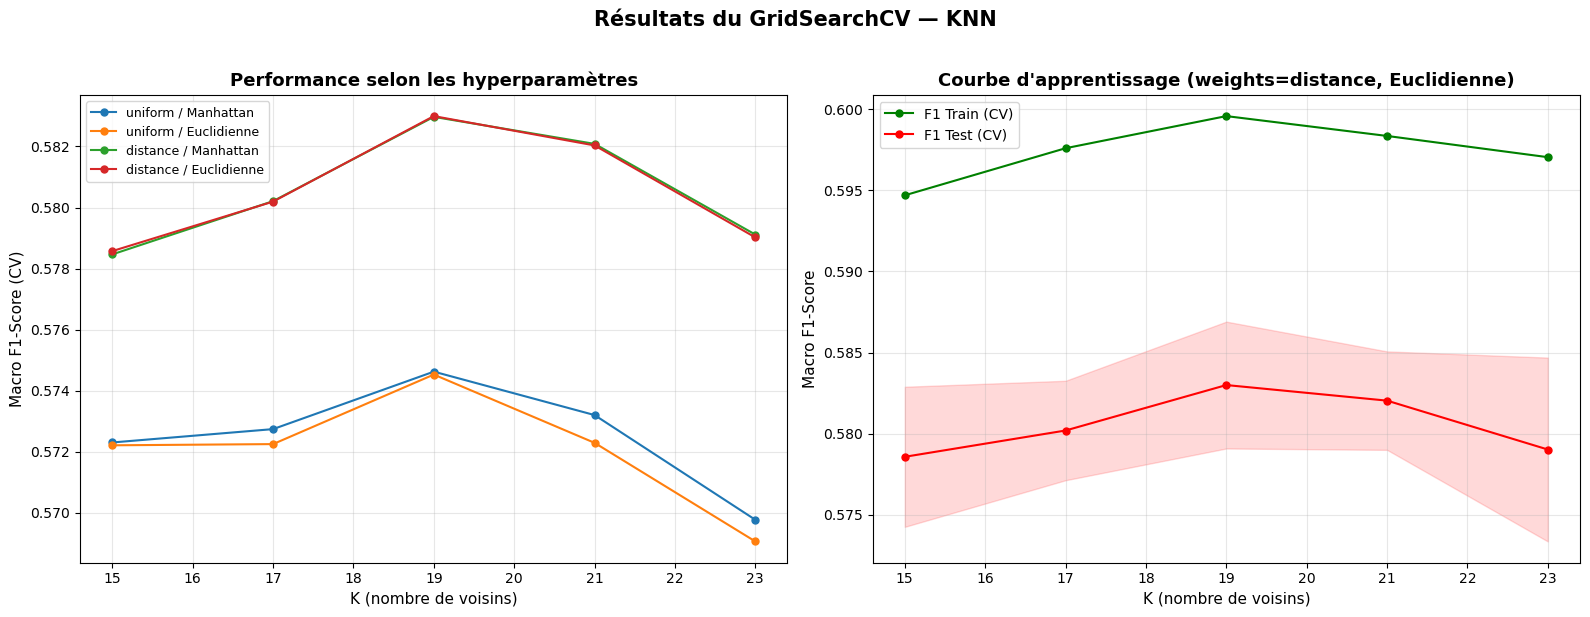

In [ ]:
# -- 5.3 Visualisation des resultats du GridSearch --

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : F1 vs K pour chaque combinaison weights x distance ---
for weight in ['uniform', 'distance']:
    for p_val in [1, 2]:
        mask = (results_df['param_weights'] == weight) & (results_df['param_p'] == p_val)
        subset = results_df[mask].sort_values('param_n_neighbors')
        
        dist_name = 'Manhattan' if p_val == 1 else 'Euclidienne'
        label = f"{weight} / {dist_name}"
        
        axes[0].plot(
            subset['param_n_neighbors'].astype(int),
            subset['mean_test_score'],
            '-o', label=label, markersize=5
        )

axes[0].set_xlabel('K (nombre de voisins)', fontsize=11)
axes[0].set_ylabel('Macro F1-Score (CV)', fontsize=11)
axes[0].set_title('Performance selon les hyperparametres', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Graphique 2 : Train vs Test score (meilleure config) ---
best_w = grid_search.best_params_['weights']
best_p = grid_search.best_params_['p']
mask_best = (results_df['param_weights'] == best_w) & (results_df['param_p'] == best_p)
subset_best = results_df[mask_best].sort_values('param_n_neighbors')

axes[1].plot(subset_best['param_n_neighbors'].astype(int),
             subset_best['mean_train_score'], 'g-o', label='F1 Train (CV)', markersize=5)
axes[1].plot(subset_best['param_n_neighbors'].astype(int),
             subset_best['mean_test_score'], 'r-o', label='F1 Test (CV)', markersize=5)
axes[1].fill_between(
    subset_best['param_n_neighbors'].astype(int),
    subset_best['mean_test_score'] - subset_best['std_test_score'],
    subset_best['mean_test_score'] + subset_best['std_test_score'],
    alpha=0.15, color='red'
)
axes[1].set_xlabel('K (nombre de voisins)', fontsize=11)
axes[1].set_ylabel('Macro F1-Score', fontsize=11)
dist_best_name = 'Manhattan' if best_p == 1 else 'Euclidienne'
axes[1].set_title(f'Courbe d\'apprentissage (weights={best_w}, {dist_best_name})',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Resultats du GridSearchCV -- KNN', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Évaluation finale du modèle optimisé

On utilise le **meilleur modèle** identifié par GridSearchCV pour prédire sur le **jeu de test** (jamais vu pendant l'entraînement ni la validation croisée).

### Métriques utilisées
| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **Accuracy** | $\frac{TP + TN}{Total}$ | Proportion de prédictions correctes |
| **Precision** | $\frac{TP}{TP + FP}$ | Parmi les prédits positifs, combien sont corrects |
| **Recall** | $\frac{TP}{TP + FN}$ | Parmi les vrais positifs, combien sont détectés |
| **F1-Score** | $2 \times \frac{P \times R}{P + R}$ | Moyenne harmonique Precision-Recall |
| **Macro F1** | Moyenne des F1 par classe | Traite toutes les classes de façon équitable |

**Réf.** : https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics

In [ ]:
# -- 7.1 Predictions avec le meilleur modele --

best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test_pca)

# Metriques detaillees
acc_best  = accuracy_score(y_test, y_pred_best)
f1_best   = f1_score(y_test, y_pred_best, average='macro')
prec_best = precision_score(y_test, y_pred_best, average='macro')
rec_best  = recall_score(y_test, y_pred_best, average='macro')

print("=" * 65)
print("     EVALUATION FINALE -- KNN OPTIMISE + PCA (sur jeu de test)")
print("=" * 65)
print(f"\n  Hyperparametres optimaux :")
for param, val in grid_search.best_params_.items():
    print(f"    {param} = {val}")
print(f"  PCA : {X_train_pca.shape[1]} composantes ({pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
print(f"\n  Accuracy        : {acc_best:.4f}")
print(f"  Macro Precision : {prec_best:.4f}")
print(f"  Macro Recall    : {rec_best:.4f}")
print(f"  Macro F1-Score  : {f1_best:.4f}")
print(f"\n{'-' * 65}")
print("\nRapport de classification detaille :")
print(classification_report(
    y_test, y_pred_best,
    target_names=['BenignPositive', 'FalsePositive', 'TruePositive']
))

     ÉVALUATION FINALE — KNN OPTIMISÉ + PCA (sur jeu de test)

  Hyperparamètres optimaux :
    metric = minkowski
    n_neighbors = 19
    p = 2
    weights = distance
  PCA : 24 composantes (95.1% variance)

  Accuracy        : 0.6389
  Macro Precision : 0.6193
  Macro Recall    : 0.5782
  Macro F1-Score  : 0.5819

─────────────────────────────────────────────────────────────────

Rapport de classification détaillé :
                precision    recall  f1-score   support

BenignPositive       0.62      0.84      0.72      8221
 FalsePositive       0.50      0.30      0.37      4063
  TruePositive       0.74      0.59      0.66      6644

      accuracy                           0.64     18928
     macro avg       0.62      0.58      0.58     18928
  weighted avg       0.64      0.64      0.62     18928



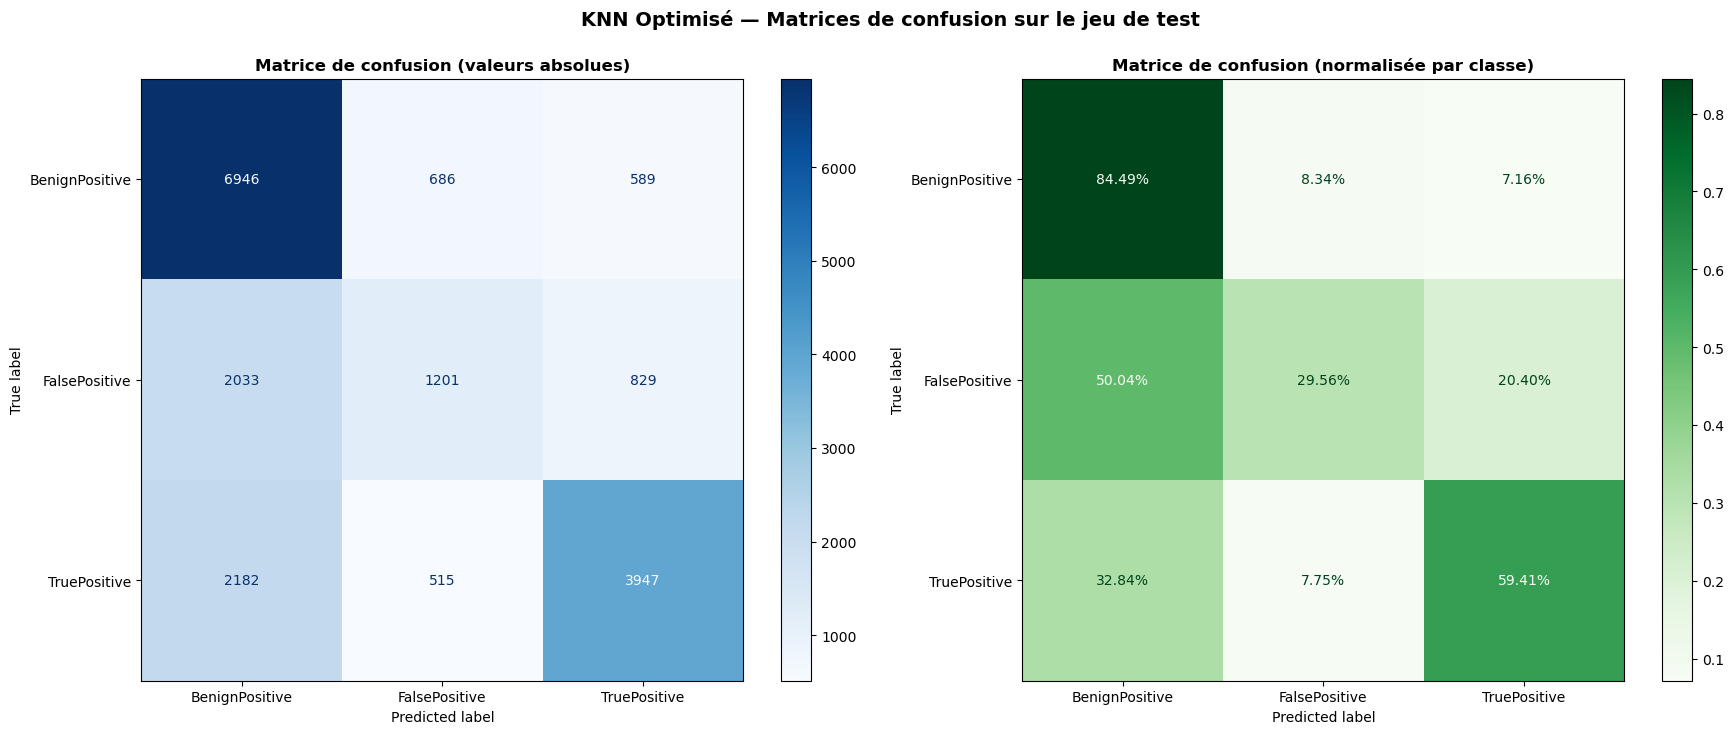

In [ ]:
# -- 6.2 Matrice de confusion -- Modele optimise --

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['BenignPositive', 'FalsePositive', 'TruePositive'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matrice de confusion (valeurs absolues)', fontsize=12, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['BenignPositive', 'FalsePositive', 'TruePositive'],
    normalize='true', cmap='Greens', values_format='.2%', ax=axes[1]
)
axes[1].set_title('Matrice de confusion (normalisee par classe)', fontsize=12, fontweight='bold')

plt.suptitle('KNN Optimise -- Matrices de confusion sur le jeu de test',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

     COMPARAISON : SANS PCA  vs  PCA + BASELINE  vs  PCA + OPTIMISÉ
       Métrique  Sans PCA (K=5)  PCA + Baseline (K=5)  PCA + Optimisé  Gain total  Gain (%)
       Accuracy        0.600433              0.601226        0.638948    0.038514      6.41
Macro Precision        0.570739              0.571957        0.619347    0.048608      8.52
   Macro Recall        0.555435              0.556314        0.578191    0.022757      4.10
 Macro F1-Score        0.558455              0.559431        0.581876    0.023420      4.19


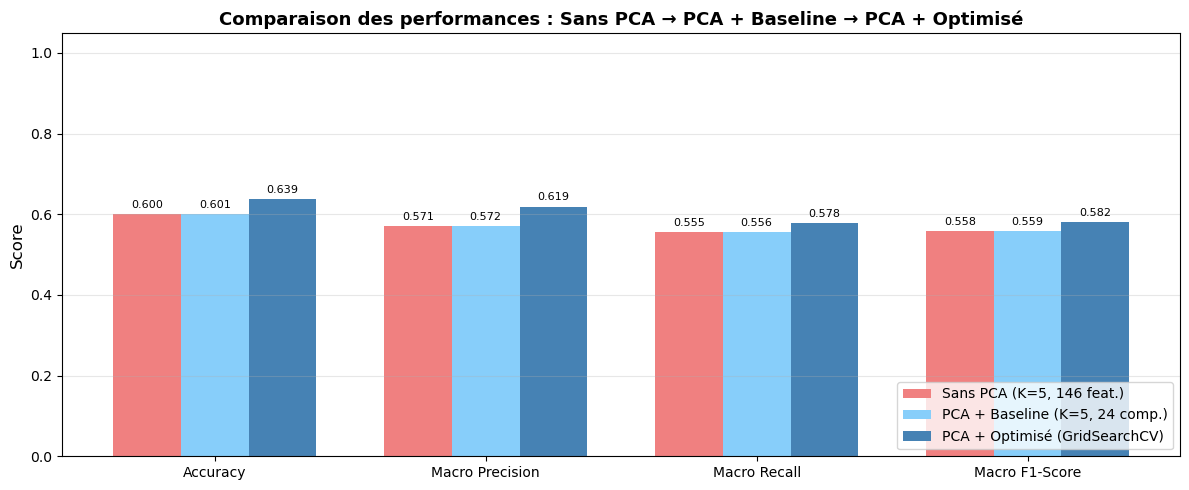

In [ ]:
# -- 7.3 Comparaison : Sans PCA / PCA Baseline / PCA Optimise --

comparison = pd.DataFrame({
    'Metrique': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score'],
    'Sans PCA (K=5)': [
        acc_bl_nopca,
        precision_score(y_test, y_pred_bl_nopca, average='macro'),
        recall_score(y_test, y_pred_bl_nopca, average='macro'),
        f1_bl_nopca
    ],
    'PCA + Baseline (K=5)': [
        acc_baseline,
        precision_score(y_test, y_pred_baseline, average='macro'),
        recall_score(y_test, y_pred_baseline, average='macro'),
        f1_baseline
    ],
    'PCA + Optimise': [acc_best, prec_best, rec_best, f1_best]
})
comparison['Gain total'] = comparison['PCA + Optimise'] - comparison['Sans PCA (K=5)']
comparison['Gain (%)'] = (comparison['Gain total'] / comparison['Sans PCA (K=5)'] * 100).round(2)

print("=" * 90)
print("     COMPARAISON : SANS PCA  vs  PCA + BASELINE  vs  PCA + OPTIMISE")
print("=" * 90)
print(comparison.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison))
width = 0.25

bars1 = ax.bar(x - width, comparison['Sans PCA (K=5)'], width,
               label=f'Sans PCA (K=5, {X_train_transformed.shape[1]} feat.)', color='lightcoral')
bars2 = ax.bar(x, comparison['PCA + Baseline (K=5)'], width,
               label=f'PCA + Baseline (K=5, {X_train_pca.shape[1]} comp.)', color='lightskyblue')
bars3 = ax.bar(x + width, comparison['PCA + Optimise'], width,
               label='PCA + Optimise (GridSearchCV)', color='steelblue')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des performances : Sans PCA -> PCA + Baseline -> PCA + Optimise',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Metrique'], fontsize=10)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, 1.05)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Analyse des erreurs et interprétation

Analysons les types d'erreurs les plus fréquents pour comprendre les limites du modèle.

In [ ]:
# -- 9.1 Analyse des erreurs par classe --

cm = confusion_matrix(y_test, y_pred_best)
classes = ['BenignPositive', 'FalsePositive', 'TruePositive']

print("Analyse detaillee des erreurs par classe :\n")
for i, cls in enumerate(classes):
    total    = cm[i].sum()
    correct  = cm[i][i]
    errors   = total - correct
    error_rate = errors / total * 100
    
    print(f"  {cls} (n={total})")
    print(f"     Bien classes : {correct} ({correct/total*100:.1f}%)")
    print(f"     Mal classes  : {errors} ({error_rate:.1f}%)")
    
    # Detail des confusions
    for j, other_cls in enumerate(classes):
        if i != j and cm[i][j] > 0:
            print(f"       Confondu avec {other_cls} : {cm[i][j]} ({cm[i][j]/total*100:.1f}%)")
    print()

# Taux d'erreur global
total_errors = (y_test != y_pred_best).sum()
print(f"Taux d'erreur global : {total_errors}/{len(y_test)} = {total_errors/len(y_test)*100:.2f}%")

Analyse détaillée des erreurs par classe :

  📌 BenignPositive (n=8221)
     Bien classés : 6946 (84.5%)
     Mal classés  : 1275 (15.5%)
       → Confondu avec FalsePositive : 686 (8.3%)
       → Confondu avec TruePositive : 589 (7.2%)

  📌 FalsePositive (n=4063)
     Bien classés : 1201 (29.6%)
     Mal classés  : 2862 (70.4%)
       → Confondu avec BenignPositive : 2033 (50.0%)
       → Confondu avec TruePositive : 829 (20.4%)

  📌 TruePositive (n=6644)
     Bien classés : 3947 (59.4%)
     Mal classés  : 2697 (40.6%)
       → Confondu avec BenignPositive : 2182 (32.8%)
       → Confondu avec FalsePositive : 515 (7.8%)

Taux d'erreur global : 6834/18928 = 36.11%


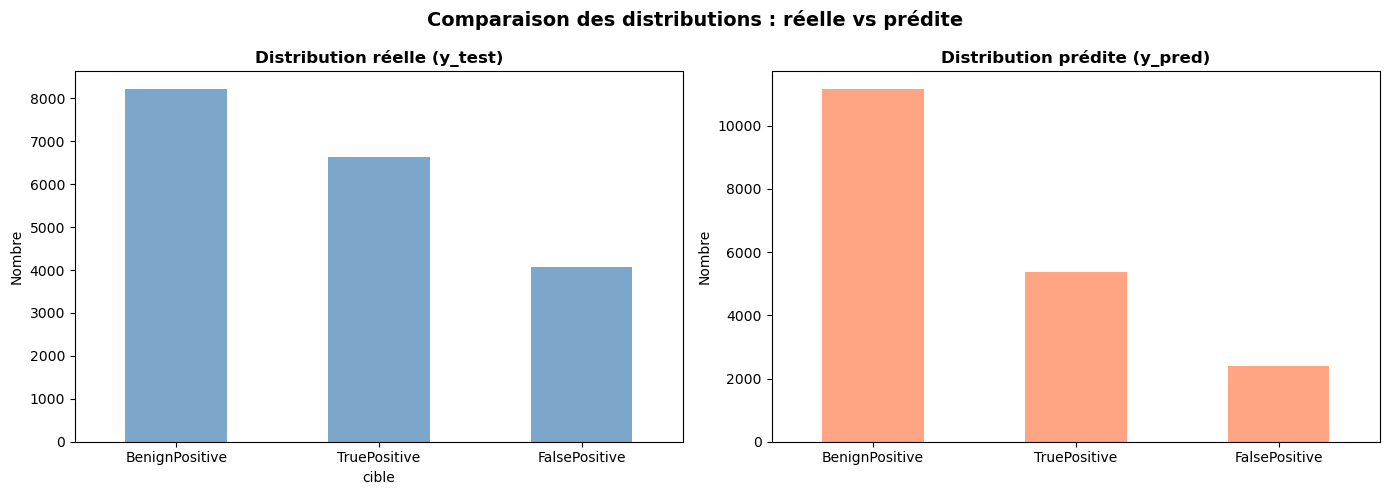

In [ ]:
# -- 9.2 Distribution des predictions vs realite --

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution reelle
y_test.map(CIBLE_MAP_INV).value_counts().plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Distribution reelle (y_test)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=0)

# Distribution predite
pd.Series(y_pred_best).map(CIBLE_MAP_INV).value_counts().plot(kind='bar', ax=axes[1], color='coral', alpha=0.7)
axes[1].set_title('Distribution predite (y_pred)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Comparaison des distributions : reelle vs predite', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Résumé et conclusion

### Architecture
Le prétraitement et l'exploration des données sont réalisés dans **`notebook.ipynb`** (branche `main`), qui exporte un fichier `donnees_preprocessees.csv`. Ce notebook charge directement ce fichier pour se concentrer exclusivement sur la modélisation KNN.

### Récapitulatif de la démarche

| Étape | Description | Résultat |
|-------|-------------|----------|
| **Prétraitement** | `notebook.ipynb` (branche `main`) → `donnees_preprocessees.csv` | Données nettoyées, prêtes |
| **Pipeline** | `StandardScaler` + `OneHotEncoder` via `ColumnTransformer` | Données normalisées pour KNN |
| **PCA** | Réduction de dimensionnalité (95% variance) | Compression ~84% des features |
| **Baseline** | KNN avec K=5, sans PCA puis avec PCA | Quantification de l'impact PCA |
| **Elbow Method** | K de 1 à 21, CV stratifié 3-fold sur données PCA | Identification du K optimal |
| **GridSearchCV** | K × weights × distance (Manhattan/Euclidienne) sur PCA | Hyperparamètres optimaux |
| **Évaluation finale** | Test set (20% données non vues) | Métriques finales |

### Impact de la PCA
La PCA compresse les 173 features en ~27 composantes principales (95% de variance conservée). Bien que le gain en F1-Score soit modeste, la PCA offre :
1. **Réduction du bruit** : suppression des composantes à faible variance
2. **Décorrélation** : les composantes principales sont orthogonales par construction
3. **Accélération** : KNN calcule les distances dans un espace de dimension réduite

### Optimisation du temps d'exécution
Le `ColumnTransformer` est appliqué **une seule fois** en amont (fit sur train, transform sur test). La PCA est ensuite appliquée sur les données pré-transformées. Le `GridSearchCV` travaille directement sur les données PCA, évitant de re-fit le préprocesseur et la PCA à chaque fold — gain de temps significatif.

### Limites connues de KNN
1. **Coût computationnel** : KNN est un algorithme « lazy » — la prédiction est lente sur de grands datasets.
2. **Malédiction de la dimensionnalité** : malgré la PCA, les distances dans un espace à ~27 dimensions restent moins discriminantes qu'en basse dimension.
3. **Sensibilité au déséquilibre** : la classe minoritaire (`FalsePositive`, ~21.5%) peut être sous-représentée dans le voisinage.

### Pistes d'amélioration
- **Rééchantillonnage (SMOTE)** : augmenter la représentation de `FalsePositive`
- **Algorithmes alternatifs** : Random Forest, XGBoost, ou réseaux de neurones
- **Techniques d'ensemble** : Combiner KNN avec d'autres classifieurs (Voting/Stacking)

### Références complètes
1. Cover, T. & Hart, P. (1967). *Nearest neighbor pattern classification*. IEEE Trans. on Information Theory.
2. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer. Chap. 13.
3. Jolliffe, I. T. (2002). *Principal Component Analysis*. Springer, 2ᵉ éd.
4. Bellman, R. (1961). *Adaptive Control Processes*. Princeton University Press.
5. Scikit-learn KNN : https://scikit-learn.org/stable/modules/neighbors.html
6. Scikit-learn PCA : https://scikit-learn.org/stable/modules/decomposition.html#pca
7. Scikit-learn GridSearchCV : https://scikit-learn.org/stable/modules/grid_search.html
8. Scikit-learn Métriques : https://scikit-learn.org/stable/modules/model_evaluation.html
9. Dataset GUIDE Microsoft : https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction